In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install spherical_geometry
# !pip install pytest

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 18.6 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
import spherical_geometry
import xml.etree.ElementTree as ET

In [ ]:
def file_coords(xml_file_path = r'E:\ISRO PS-Transformer\DataSet\OHRC\ch2_ohr_nrp_20200229T0938004033_d_img_d32\data\raw\20200229\ch2_ohr_nrp_20200229T0938004033_d_img_d32.xml'):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()

    # Define the namespace dictionary
    namespace = {
        'isda': 'https://isda.issdc.gov.in/pds4/isda/v1',
    }

    # Function to extract latitude and longitude values
    def extract_coordinates(element):
        coordinates = element.find('.//isda:System_Level_Coordinates', namespace)
        upper_left_latitude = coordinates.find('./isda:upper_left_latitude', namespace).text
        upper_left_longitude = coordinates.find('./isda:upper_left_longitude', namespace).text

        upper_right_latitude = coordinates.find('./isda:upper_right_latitude', namespace).text
        upper_right_longitude = coordinates.find('./isda:upper_right_longitude', namespace).text

        lower_left_latitude = coordinates.find('./isda:lower_left_latitude', namespace).text
        lower_left_longitude = coordinates.find('./isda:lower_left_longitude', namespace).text

        lower_right_latitude = coordinates.find('./isda:lower_right_latitude', namespace).text
        lower_right_longitude = coordinates.find('./isda:lower_right_longitude', namespace).text

        return [(lower_left_longitude, lower_left_latitude), (lower_right_longitude, lower_right_latitude), (upper_right_longitude, upper_right_latitude), (upper_left_longitude, upper_left_latitude)]

    # Extract coordinates from the XML
    coordinates = extract_coordinates(root)
    # Print the results
    return coordinates
# Function to find XML files and generate PNG file link
def parse_xml_and_get_png(xml_file_path, base_dir):
    # Extracting information from XML file path
    xml_filename = os.path.basename(xml_file_path)
    date_folder = os.path.basename(os.path.dirname(xml_file_path))
    channel = xml_filename.split('_')[0]

    # Creating corresponding PNG file path
    png_filename = xml_filename.replace('d_img', 'b_brw').replace('.xml', '.png')
    png_file_path = os.path.join(base_dir, 'browse', 'calibrated', date_folder, png_filename)

    return png_file_path

# Function to parse all XML files under the 'data\calibrated' directory and create a dictionary
def parse_all_xml_files(directory, base_dir):
    xml_files_dict = {}
    for root, dirs, files in os.walk(os.path.join(base_dir, 'data', 'calibrated')):
        for file in files:
            if file.endswith('.xml'):
                xml_file_path = os.path.join(root, file)
                png_file_path = parse_xml_and_get_png(xml_file_path, base_dir)
                xml_files_dict[file] = [file_coords(xml_file_path), png_file_path]

    return xml_files_dict

In [ ]:
def iterate_tmc(base_dir, coor_csv):
    tmc_files = {}
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root, file)
                filename =file.split('_b')[0]
                row = coor_csv[coor_csv['Filename'].str.startswith(filename)]
                upper_left_latitude = row['upper_left_latitude'].iloc[0]
                upper_left_longitude = row['upper_left_longitude'].iloc[0]

                upper_right_latitude = row['upper_right_latitude'].iloc[0]
                upper_right_longitude = row['upper_right_longitude'].iloc[0]

                lower_left_latitude = row['lower_left_latitude'].iloc[0]
                lower_left_longitude = row['lower_left_longitude'].iloc[0]

                lower_right_latitude = row['lower_right_latitude'].iloc[0]
                lower_right_longitude = row['lower_right_longitude'].iloc[0]

                tmc_files[file] = [[(lower_left_longitude, lower_left_latitude), (lower_right_longitude, lower_right_latitude), (upper_right_longitude, upper_right_latitude), (upper_left_longitude, upper_left_latitude)], file_path]

    return tmc_files

In [ ]:
coor_csv = pd.read_csv(r"/content/drive/MyDrive/Moon Mapping/DataSet/TMC/coordinates.csv")
coor_csv.sample()

,S.no,Filename,Start Time,End TIme,Size,Altitude,Unnamed: 6,upper_left_latitude,upper_left_longitude,upper_right_latitude,upper_right_longitude,lower_left_latitude,lower_left_longitude,lower_right_latitude,lower_right_longitude,projection,Area
2058,2059,ch2_tmc_ncn_20210720T2333035757_d_img_d32.zip,2021-07-20T23:33:03.575Z,2021-07-20T23:41:00.323Z,1178608000,115.55,View,7.054831,15.970056,7.055161,15.199975,-16.840721,15.844733,-16.838414,15.041161,Selenographic,Equatorial


In [ ]:
base_dir = r'/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files'
xml_files_dict_ohrc = parse_all_xml_files(os.path.join(base_dir, 'data', 'calibrated'), base_dir)

xml_files_dict_tmc = iterate_tmc(r'/content/drive/MyDrive/Moon Mapping/DataSet/TMC', coor_csv)

In [ ]:
xml_files_dict_tmc_items = xml_files_dict_tmc.items()
list(xml_files_dict_tmc_items)[0]

('ch2_tmc_ncf_20191207T1633073885_b_brw_d18.png',
 [[(71.654291, 28.51981),
   (72.406323, 28.500514),
   (71.808675, -1.191494),
   (71.163227, -1.174016)],
  '/content/drive/MyDrive/Moon Mapping/DataSet/TMC/browse_calibrated_2019/dir_2019/20191207/ch2_tmc_ncf_20191207T1633073885_b_brw_d18.png'])

In [ ]:
xml_files_dict_ohrc_items = xml_files_dict_ohrc.items()
list(xml_files_dict_ohrc_items)[0]

('ch2_ohr_ncp_20230823T0858341949_d_img_n18.xml',
 [[('32.031939', '-69.820702'),
   ('32.351364', '-69.823800'),
   ('32.504543', '-68.993974'),
   ('32.196504', '-68.991177')],
  '/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files/browse/calibrated/20230823/ch2_ohr_ncp_20230823T0858341949_b_brw_n18.png'])

In [ ]:
# First Lets start by Creating a Polygon using the co-ordimate of a image

from spherical_geometry import graph, great_circle_arc, polygon, vector

img_1_details = list(xml_files_dict_tmc_items)[0]
img_1_corners = img_1_details[1][0]
print(img_1_corners)

coordinates_xyz = [vector.normalize_vector(vector.lonlat_to_vector(float(lon), float(lat), degrees=True)) for lon, lat in img_1_corners]


inside_point = great_circle_arc.midpoint(coordinates_xyz[0], coordinates_xyz[2])
polygon = polygon.SingleSphericalPolygon(coordinates_xyz, inside=inside_point)

# polygon.is_clockwise()
# polygon.__len__
points = polygon.to_lonlat()
print(points)

[(71.654291, 28.51981), (72.406323, 28.500514), (71.808675, -1.191494), (71.163227, -1.174016)]
(array([71.654291, 72.406323, 71.808675, 71.163227, 71.654291]), array([28.51981 , 28.500514, -1.191494, -1.174016, 28.51981 ]))


In [ ]:
from spherical_geometry import graph, great_circle_arc, polygon, vector
def SphericalPoly(img_corners):
  coordinates_xyz = [vector.normalize_vector(vector.lonlat_to_vector(float(lon), float(lat), degrees=True)) for lon, lat in img_corners]
  inside_point = great_circle_arc.midpoint(coordinates_xyz[0], coordinates_xyz[2])
  poly = polygon.SingleSphericalPolygon(coordinates_xyz, inside=inside_point)
  return poly

In [ ]:
len(xml_files_dict_ohrc)

49

In [ ]:
column_names = ["Tmc_Image", "Tmc_File_Location", "Tmc_Corners", "Tmc_Polygon", "Ohrc_Image", "Ohrc_File_Location", "Ohrc_Corners", "Ohrc_Polygon", "Intersecting_Corners", "Intersecting_Polygon"]

df = pd.DataFrame(columns=column_names)

In [ ]:
df

,Tmc_Image,Tmc_File_Location,Tmc_Corners,Tmc_Polygon,Ohrc_Image,Ohrc_File_Location,Ohrc_Corners,Ohrc_Polygon,Intersecting_Corners,Intersecting_Polygon


In [ ]:
xml_files_dict_ohrc

{'ch2_ohr_ncp_20230823T0858341949_d_img_n18.xml': [[('32.031939',
    '-69.820702'),
   ('32.351364', '-69.823800'),
   ('32.504543', '-68.993974'),
   ('32.196504', '-68.991177')],
  '/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files/browse/calibrated/20230823/ch2_ohr_ncp_20230823T0858341949_b_brw_n18.png'],
 'ch2_ohr_ncp_20230823T1647285085_d_img_n18.xml': [[('32.125308',
    '-69.760205'),
   ('32.438643', '-69.764695'),
   ('32.439167', '-68.933520'),
   ('32.137000', '-68.929006')],
  '/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files/browse/calibrated/20230823/ch2_ohr_ncp_20230823T1647285085_b_brw_n18.png'],
 'ch2_ohr_ncp_20230823T1647285315_d_img_n18.xml': [[('32.131435',
    '-69.690155'),
   ('32.442350', '-69.694548'),
   ('32.442774', '-68.863556'),
   ('32.142894', '-68.859140')],
  '/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files/browse/calibrated/20230823/ch2_ohr_ncp_20230823T1647285315_b_brw_n18.png'],
 'ch2_ohr_ncp_20230823T1450475804_d_img_n18.xml': [[

In [ ]:
for image_tmc in xml_files_dict_tmc:
  poly_tmc = SphericalPoly(xml_files_dict_tmc[image_tmc][0])
  for image_ohrc in xml_files_dict_ohrc:
    if(not(np.isnan(xml_files_dict_tmc[image_tmc][0])).any()):
      print(xml_files_dict_tmc[image_tmc][0])
      print(xml_files_dict_ohrc[image_ohrc][0])

In [ ]:
iterator = 0

for image_tmc in xml_files_dict_tmc:
  poly_tmc = SphericalPoly(xml_files_dict_tmc[image_tmc][0])
  for image_ohrc in xml_files_dict_ohrc:
    if(not(np.isnan(xml_files_dict_tmc[image_tmc][0])).any()):
      poly_ohrc = SphericalPoly(xml_files_dict_ohrc[image_ohrc][0])
      if(poly_ohrc.intersects_poly(poly_tmc)):
        temp = []
        print("a")
        temp.append(image_tmc)
        temp.append(xml_files_dict_tmc[image_tmc][1])
        temp.append(poly_tmc.to_lonlat())
        temp.append(poly_tmc)

        print("b")
        temp.append(image_ohrc)
        temp.append(xml_files_dict_ohrc[image_ohrc][1])
        temp.append(poly_ohrc.to_lonlat())
        temp.append(poly_ohrc)


        intersection = poly_ohrc.intersection(poly_tmc)
        print("c")
        temp.append(list(intersection.to_lonlat())[0])
        temp.append(intersection)

        df.loc[len(df.index)] = temp
        iterator += 1
        print(iterator)


a
b
c
1


/usr/local/lib/python3.10/dist-packages/spherical_geometry/vector.py:152: RuntimeWarning: invalid value encountered in normalize
  math_util.normalize(xyz, output)
/usr/local/lib/python3.10/dist-packages/spherical_geometry/polygon.py:597: RuntimeWarning: invalid value encountered in triple_product
  orient = great_circle_arc.triple_product(A-B, C-B, B)
/usr/local/lib/python3.10/dist-packages/spherical_geometry/polygon.py:135: RuntimeWarning: invalid value encountered in triple_product
  orient = great_circle_arc.triple_product(A-B, C-B, B)


a
b
c
2
a
b
c
3


/usr/local/lib/python3.10/dist-packages/spherical_geometry/vector.py:152: RuntimeWarning: invalid value encountered in normalize
  math_util.normalize(xyz, output)
/usr/local/lib/python3.10/dist-packages/spherical_geometry/polygon.py:597: RuntimeWarning: invalid value encountered in triple_product
  orient = great_circle_arc.triple_product(A-B, C-B, B)
/usr/local/lib/python3.10/dist-packages/spherical_geometry/polygon.py:135: RuntimeWarning: invalid value encountered in triple_product
  orient = great_circle_arc.triple_product(A-B, C-B, B)


a
b
c
4
a
b
c
5
a
b
c
6
a
b
c
7


...

a
b
c
22
a
b
c
23
a
b
c
24
a
b
c
25
a
b
c
26
a
b
c
27
a
b
c
28
a
b
c
29


/usr/local/lib/python3.10/dist-packages/spherical_geometry/vector.py:152: RuntimeWarning: invalid value encountered in normalize
  math_util.normalize(xyz, output)
/usr/local/lib/python3.10/dist-packages/spherical_geometry/polygon.py:597: RuntimeWarning: invalid value encountered in triple_product
  orient = great_circle_arc.triple_product(A-B, C-B, B)
/usr/local/lib/python3.10/dist-packages/spherical_geometry/polygon.py:135: RuntimeWarning: invalid value encountered in triple_product
  orient = great_circle_arc.triple_product(A-B, C-B, B)


a
b
c
30
a
b
c
31
a
b
c
32
a
b
c
33


/usr/local/lib/python3.10/dist-packages/spherical_geometry/vector.py:152: RuntimeWarning: invalid value encountered in normalize
  math_util.normalize(xyz, output)
/usr/local/lib/python3.10/dist-packages/spherical_geometry/polygon.py:597: RuntimeWarning: invalid value encountered in triple_product
  orient = great_circle_arc.triple_product(A-B, C-B, B)
/usr/local/lib/python3.10/dist-packages/spherical_geometry/polygon.py:135: RuntimeWarning: invalid value encountered in triple_product
  orient = great_circle_arc.triple_product(A-B, C-B, B)


a
b
c
34
a
b
c
35
a
b
c
36
a
b
c
37
a
b
c
38
a
b
c
39
a
b
c
40
a
b
c
41
a
b
c
42
a
b
c
43
a
b
c
44
a
b
c
45
a
b
c
46
a
b
c
47
a
b
c
48
a
b
c
49
a
b
c
50
a
b
c
51
a
b
c
52
a
b
c
53
a
b
c
54
a
b
c
55
a
b
c
56
a
b
c
57
a
b
c
58
a
b
c
59
a
b
c
60
a
b
c
61
a
b
c
62
a
b
c
63
a
b
c
64
a
b
c
65
a
b
c
66
a
b
c
67
a
b
c
68
a
b
c
69
a
b
c
70
a
b
c
71
a
b
c
72
a
b
c
73
a
b
c
74
a
b
c
75
a
b
c
76
a
b
c
77
a
b
c
78
a
b
c
79
a
b
c
80
a
b
c
81
a
b
c
82
a
b
c
83
a
b
c
84
a
b
c
85
a
b
c
86
a
b
c
87
a
b
c
88
a
b
c
89
a
b
c
90
a
b
c
91
a
b
c
92
a
b
c
93
a
b
c
94
a
b
c
95
a
b
c
96
a
b
c
97
a
b
c
98
a
b
c
99
a
b
c
100
a
b
c
101
a
b
c
102
a
b
c
103
a
b
c
104
a
b
c
105
a
b
c
106
a
b
c
107
a
b
c
108
a
b
c
109
a
b
c
110
a
b
c
111
a
b
c
112
a
b
c
113
a
b
c
114
a
b
c
115
a
b
c
116
a
b
c
117
a
b
c
118
a
b
c
119
a
b
c
120
a
b
c
121
a
b
c
122
a
b
c
123
a
b
c
124
a
b
c
125
a
b
c
126
a
b
c
127
a
b
c
128
a
b
c
129
a
b
c
130
a
b
c
131
a
b
c
132
a
b
c
133
a
b
c
134
a
b
c
135
a
b
c
136
a
b
c
137
a
b
c
138
a
b
c
139
a
b
c


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 785 entries, 0 to 784
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Tmc_Image             785 non-null    object
 1   Tmc_File_Location     785 non-null    object
 2   Tmc_Corners           785 non-null    object
 3   Tmc_Polygon           785 non-null    object
 4   Ohrc_Image            785 non-null    object
 5   Ohrc_File_Location    785 non-null    object
 6   Ohrc_Corners          785 non-null    object
 7   Ohrc_Polygon          785 non-null    object
 8   Intersecting_Corners  785 non-null    object
 9   Intersecting_Polygon  785 non-null    object
dtypes: object(10)
memory usage: 67.5+ KB


In [ ]:
q = new.to_lonlat()
print(list(q))

[(array([100.47295886, 100.531295  , 100.54432483, 100.47295886]), array([-72.23491886, -72.234792  , -72.77925604, -72.23491886]))]


In [ ]:
import matplotlib.pyplot as plt

# Assuming poly_ohrc, poly_tmc, and new are your SphericalPolygon objects

# Extract coordinates for plotting
ohrc_lonlat = list(a.to_lonlat())
tmc_lonlat = list(b.to_lonlat())
new_lonlat = list(new.to_lonlat())

# Plotting
plt.figure(figsize=(8, 6))

# Plot original polygons
plt.plot(ohrc_lonlat[0] + [ohrc_lonlat[0][0]], ohrc_lonlat[1] + [ohrc_lonlat[1][0]], label='OHRC Polygon', color='blue')
plt.plot(tmc_lonlat[0] + [tmc_lonlat[0][0]], tmc_lonlat[1] + [tmc_lonlat[1][0]], label='TMC Polygon', color='orange')

# Plot intersection patch
plt.plot(new_lonlat[0] + [new_lonlat[0][0]], new_lonlat[1] + [new_lonlat[1][0]], label='Intersection Patch', color='green')

# Set plot labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Intersection Visualization')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
a.intersects_poly(b)

In [ ]:
print(a,"\n",b,"\n",c,"\n",d,"\n",e,"\n",new,"\n")

In [ ]:
new

In [ ]:
poly_ohrc.intersects_poly(poly_tmc)

In [ ]:
new

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def cartesian_to_spherical(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z/r)
    phi = np.arctan2(y, x)
    return r, theta, phi

# Example points in Cartesian coordinates
x_points = [pts[0] for pts in points]
y_points = [pts[1] for pts in points]
z_points = [pts[2] for pts in points]

# Convert Cartesian coordinates to spherical coordinates
r_points, theta_points, phi_points = zip(*[cartesian_to_spherical(x, y, z) for x, y, z in zip(x_points, y_points, z_points)])

# Convert spherical coordinates to Cartesian coordinates for plotting
x_sphere = r_points * np.sin(theta_points) * np.cos(phi_points)
y_sphere = r_points * np.sin(theta_points) * np.sin(phi_points)
z_sphere = r_points * np.cos(theta_points)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting the sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='c', alpha=0.3, label='Sphere')

# Plotting points on the sphere with a specific color
sc = ax.plot(x_sphere, y_sphere, z_sphere, c='red', marker='o', label='Points on Sphere')

# # Manually specify legend handles and labels
# handles, labels = sc.legend_elements()
# ax.legend(handles, labels, loc='upper right')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Points on a Sphere')

plt.show()


In [ ]:
x_sphere

In [ ]:
y_sphere

In [ ]:
z_sphere

In [ ]:
polygon

In [ ]:
inside_point

In [ ]:
coordinates_xyz

In [ ]:
cartesian_xyz

In [ ]:
xyz

In [ ]:
img_1_corners

TypeError: float() argument must be a string or a real number, not 'Point'

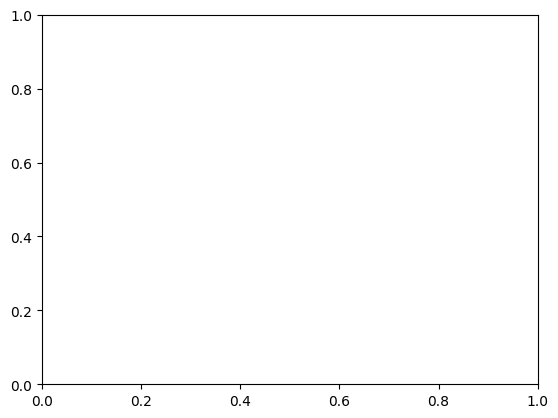

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Create a GeoDataFrame
df = gpd.GeoDataFrame({'geometry': gpd.points_from_xy([100, 100], [200, 400])})
df1 = gpd.GeoDataFrame({'geometry': gpd.points_from_xy([200, 200], [400, 800])})
# Plot the GeoDataFrame


# Add a title and axis labels
plt.title('Plot of Latitude and Longitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Create a list of coordinates for each polygon
polygons = [[[100, 100], [200, 200], [300, 300], [100, 100]], [[400, 400], [500, 500], [600, 600], [400, 400]]]

# Create a GeoDataFrame from the list of coordinates
df = gpd.GeoDataFrame({'geometry': [gpd.Polygon(polygon) for polygon in polygons]})

# Plot the GeoDataFrame
df.plot()

# Add a title and axis labels
plt.title('Plot of Polygons')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

AttributeError: module 'geopandas' has no attribute 'Polygon'